<a href="https://colab.research.google.com/github/dhanwariagarvit21/information-diffusion-/blob/main/standardized_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
!pip install pyarrow -q

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
index_sp500 = pd.read_parquet('/content/download/index_SPX500_USD_30s.parquet')
AAPl = pd.read_parquet('/content/download/stocks_AAPL_30s.parquet')
MSFT = pd.read_parquet('/content/download/stocks_MSFT_30s.parquet')
NVDA = pd.read_parquet('/content/download/stocks_NVDA_30s.parquet')
TSLA = pd.read_parquet('/content/download/stocks_TSLA_30s.parquet')
JNJ = pd.read_parquet('/content/download/stocks_JNJ_30s.parquet')
JPM = pd.read_parquet('/content/download/stocks_JPM_30s.parquet')
WMT = pd.read_parquet('/content/download/stocks_WMT_30s.parquet')
XOM = pd.read_parquet('/content/download/stocks_XOM_30s.parquet')
events = pd.read_csv('/content/download/information_diffusion_US8_core_events_2025-09-01_to_2026-09-01_UK_time.csv')

In [54]:
def to_et(df):
    df = df.copy()
    df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('America/New_York')
    return df

index_sp500, AAPl, MSFT, NVDA, TSLA, JNJ, JPM, WMT, XOM = [
    to_et(df) for df in (index_sp500, AAPl, MSFT, NVDA, TSLA, JNJ, JPM, WMT, XOM)
]

In [55]:
def trim_to_hours(df, start='09:30:00', end='16:00:00'):
    t = df['ts'].dt.time
    return df[(t >= pd.to_datetime(start).time()) & (t <= pd.to_datetime(end).time())]

MSFT, AAPl, NVDA, TSLA, JNJ, JPM, WMT, XOM, index_sp500 = [
    trim_to_hours(df) for df in (MSFT, AAPl, NVDA, TSLA, JNJ, JPM, WMT, XOM, index_sp500)
]

In [56]:
def prepare_df_for_merge(df):
    symbol = df['symbol'].iloc[0]
    df = df.set_index('ts')
    df = df.drop(columns=['symbol'])
    df.columns = [f'{symbol}_{col}' for col in df.columns]
    return df

index_sp500_prepared = prepare_df_for_merge(index_sp500)
aapl_prepared = prepare_df_for_merge(AAPl)
msft_prepared = prepare_df_for_merge(MSFT)
nvda_prepared = prepare_df_for_merge(NVDA)
tsla_prepared = prepare_df_for_merge(TSLA)
jnj_prepared = prepare_df_for_merge(JNJ)
jpm_prepared = prepare_df_for_merge(JPM)
wmt_prepared = prepare_df_for_merge(WMT)
xom_prepared = prepare_df_for_merge(XOM)

In [57]:
merged_side_by_side_df = index_sp500_prepared
for other in [aapl_prepared, msft_prepared, nvda_prepared, tsla_prepared,
              jnj_prepared, jpm_prepared, wmt_prepared, xom_prepared]:
    merged_side_by_side_df = pd.merge(merged_side_by_side_df, other,
                                       left_index=True, right_index=True, how='outer')

merged_side_by_side_df.head()

,SPX500/USD_open,SPX500/USD_high,SPX500/USD_low,SPX500/USD_close,SPX500/USD_volume,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume,...,WMT_open,WMT_high,WMT_low,WMT_close,WMT_volume,XOM_open,XOM_high,XOM_low,XOM_close,XOM_volume
ts,,,,,,,,,,,,,,,,,,,,,
2025-09-02 09:30:00-04:00,6401.51,6401.51,6374.71,6374.71,0.0,229.43,229.70,229.05,229.23,1534749.0,...,97.18,97.71,97.00,97.35,993855.0,114.12,114.38,114.00,114.33,8824.0
2025-09-02 09:30:30-04:00,6374.84,6377.77,6373.50,6373.81,0.0,229.19,229.22,228.55,228.60,141878.0,...,97.35,97.37,97.11,97.13,81845.0,114.25,114.38,114.21,114.25,1844.0
2025-09-02 09:31:00-04:00,6373.45,6374.09,6372.00,6372.52,0.0,228.64,228.79,228.24,228.41,122604.0,...,97.16,97.25,97.11,97.17,52742.0,114.33,114.55,114.25,114.46,10723.0
2025-09-02 09:31:30-04:00,6371.81,6372.62,6369.57,6371.70,0.0,228.41,228.66,227.90,228.24,111813.0,...,97.18,97.31,97.14,97.28,28794.0,114.47,114.60,114.30,114.44,4333.0
2025-09-02 09:32:00-04:00,6371.18,6373.73,6369.85,6371.67,0.0,228.22,228.27,227.67,227.91,126118.0,...,97.30,97.44,97.23,97.40,46662.0,114.45,114.60,114.31,114.58,4201.0


In [58]:
events['datetime_utc'] = pd.to_datetime(events['datetime_utc'], utc=True)
events['datetime_us']  = events['datetime_utc'].dt.tz_convert('America/New_York')
events.head()

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us
0,1,2025-09-17,14:00,2025-09-17 18:00:00+00:00,2025-09-17 19:00:00 BST,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
1,2,2025-10-14,06:38,2025-10-14 10:38:00+00:00,2025-10-14 11:38:00 BST,11:38:00,2025-10-14 06:38:00 EDT,2025-10-14 06:38:00 EDT,JPM,JPMorgan Chase & Co.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-14 06:38:00-04:00
2,3,2025-10-14,06:40,2025-10-14 10:40:00+00:00,2025-10-14 11:40:00 BST,11:40:00,2025-10-14 06:40:00 EDT,2025-10-14 06:40:00 EDT,JNJ,Johnson & Johnson,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-14 06:40:00-04:00
3,4,2025-10-22,16:05,2025-10-22 20:05:00+00:00,2025-10-22 21:05:00 BST,21:05:00,2025-10-22 16:05:00 EDT,2025-10-22 16:05:00 EDT,TSLA,Tesla Inc.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-22 16:05:00-04:00
4,5,2025-10-29,14:00,2025-10-29 18:00:00+00:00,2025-10-29 18:00:00 GMT,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 14:00:00-04:00


In [59]:
mkt_start, mkt_end = pd.to_datetime('09:30:00').time(), pd.to_datetime('16:00:00').time()
events_trimmed = events[
    (events['datetime_us'].dt.time > mkt_start) &
    (events['datetime_us'].dt.time < mkt_end)
].copy()
events_trimmed['date'] = events_trimmed['datetime_us'].dt.date
events_trimmed

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us
0,1,2025-09-17,14:00,2025-09-17 18:00:00+00:00,2025-09-17 19:00:00 BST,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
4,5,2025-10-29,14:00,2025-10-29 18:00:00+00:00,2025-10-29 18:00:00 GMT,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 14:00:00-04:00
10,11,2025-12-10,14:00,2025-12-10 19:00:00+00:00,2025-12-10 19:00:00 GMT,19:00:00,2025-12-10 14:00:00 EST,2025-12-10 14:00:00 EST,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-12-10 14:00:00-05:00
13,14,2026-01-28,14:00,2026-01-28 19:00:00+00:00,2026-01-28 19:00:00 GMT,19:00:00,2026-01-28 14:00:00 EST,2026-01-28 14:00:00 EST,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-01-28 14:00:00-05:00
20,21,2026-03-18,14:00,2026-03-18 18:00:00+00:00,2026-03-18 18:00:00 GMT,18:00:00,2026-03-18 14:00:00 EDT,2026-03-18 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-03-18 14:00:00-04:00
24,25,2026-04-29,14:00,2026-04-29 18:00:00+00:00,2026-04-29 19:00:00 BST,19:00:00,2026-04-29 14:00:00 EDT,2026-04-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-04-29 14:00:00-04:00
30,31,2026-06-17,14:00,2026-06-17 18:00:00+00:00,2026-06-17 19:00:00 BST,19:00:00,2026-06-17 14:00:00 EDT,2026-06-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-06-17 14:00:00-04:00
34,35,2026-07-29,14:00,2026-07-29 18:00:00+00:00,2026-07-29 19:00:00 BST,19:00:00,2026-07-29 14:00:00 EDT,2026-07-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00


In [60]:
rate_decision_percentage = ['4.125','3.875','3.625','3.625','3.625','3.625','3.625','3.625']
events_trimmed['rate_decision_percentage'] = rate_decision_percentage
events_sorted = events_trimmed.sort_values('datetime_us').reset_index(drop=True)
events_sorted['rate_decision_percentage'] = pd.to_numeric(rate_decision_percentage)

events_sorted['rate_change'] = events_sorted['rate_decision_percentage'].diff()
events_sorted['direction'] = np.select(
    [events_sorted['rate_change'] > 0, events_sorted['rate_change'] < 0],
    ['hike', 'cut'],
    default='hold'
)
events_sorted[['event_id','datetime_us','rate_decision_percentage','rate_change','direction']]

,event_id,datetime_us,rate_decision_percentage,rate_change,direction
0,1,2025-09-17 14:00:00-04:00,4.125,NaN,hold
1,5,2025-10-29 14:00:00-04:00,3.875,-0.25,cut
2,11,2025-12-10 14:00:00-05:00,3.625,-0.25,cut
3,14,2026-01-28 14:00:00-05:00,3.625,0.00,hold
4,21,2026-03-18 14:00:00-04:00,3.625,0.00,hold
5,25,2026-04-29 14:00:00-04:00,3.625,0.00,hold
6,31,2026-06-17 14:00:00-04:00,3.625,0.00,hold
7,35,2026-07-29 14:00:00-04:00,3.625,0.00,hold


In [61]:
events_trimmed

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us,rate_decision_percentage
0,1,2025-09-17,14:00,2025-09-17 18:00:00+00:00,2025-09-17 19:00:00 BST,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00,4.125
4,5,2025-10-29,14:00,2025-10-29 18:00:00+00:00,2025-10-29 18:00:00 GMT,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 14:00:00-04:00,3.875
10,11,2025-12-10,14:00,2025-12-10 19:00:00+00:00,2025-12-10 19:00:00 GMT,19:00:00,2025-12-10 14:00:00 EST,2025-12-10 14:00:00 EST,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-12-10 14:00:00-05:00,3.625
13,14,2026-01-28,14:00,2026-01-28 19:00:00+00:00,2026-01-28 19:00:00 GMT,19:00:00,2026-01-28 14:00:00 EST,2026-01-28 14:00:00 EST,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-01-28 14:00:00-05:00,3.625
20,21,2026-03-18,14:00,2026-03-18 18:00:00+00:00,2026-03-18 18:00:00 GMT,18:00:00,2026-03-18 14:00:00 EDT,2026-03-18 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-03-18 14:00:00-04:00,3.625
24,25,2026-04-29,14:00,2026-04-29 18:00:00+00:00,2026-04-29 19:00:00 BST,19:00:00,2026-04-29 14:00:00 EDT,2026-04-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-04-29 14:00:00-04:00,3.625
30,31,2026-06-17,14:00,2026-06-17 18:00:00+00:00,2026-06-17 19:00:00 BST,19:00:00,2026-06-17 14:00:00 EDT,2026-06-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-06-17 14:00:00-04:00,3.625
34,35,2026-07-29,14:00,2026-07-29 18:00:00+00:00,2026-07-29 19:00:00 BST,19:00:00,2026-07-29 14:00:00 EDT,2026-07-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00,3.625


In [62]:

def beta_calculator(df, stock_name, event_time, exclude_dates=None,
                     lookback_days=30, mkst="13:00", mket="16:00", freq="1min"):
    end_date = (event_time - pd.Timedelta(days=1)).date()
    start_date = (event_time - pd.Timedelta(days=lookback_days)).date()
    date_mask = (df.index.date >= start_date) & (df.index.date <= end_date)
    filtered_df = df[date_mask].copy()

    if exclude_dates:
        exclude_mask = pd.Index(filtered_df.index.date).isin(exclude_dates)
        filtered_df = filtered_df[~exclude_mask]

    px = filtered_df[[f'{stock_name}_close', 'SPX500/USD_close']].resample(freq).last().dropna()
    if px.empty:
        return np.nan
    ret = px.groupby(px.index.normalize()).apply(lambda g: np.log(g).diff()).droplevel(0)
    ret = ret.dropna().between_time(mkst, mket)

    if ret.empty:
        return np.nan
    cov = ret[f'{stock_name}_close'].cov(ret['SPX500/USD_close'])
    var = ret['SPX500/USD_close'].var()

    if var == 0:
        return np.nan

    return cov / var


stocks_name = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'JNJ', 'JPM', 'WMT', 'XOM']
events_date = pd.to_datetime(events_trimmed['date'])
all_event_dates = set(events_date.dt.date)

betas = {name: [] for name in stocks_name}
for stock_name in stocks_name:
    for event_time in events_date:
        exclude = all_event_dates - {event_time.date()}
        betas[stock_name].append(
            beta_calculator(merged_side_by_side_df, stock_name, event_time,
                             exclude_dates=exclude)
        )

beta_df = pd.DataFrame(betas, index=events_date)
beta_df.describe()

,AAPL,MSFT,NVDA,TSLA,JNJ,JPM,WMT,XOM
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.997561,0.970422,1.777621,1.793430,0.247434,0.879629,0.361566,0.181405
std,0.170350,0.138406,0.248580,0.207246,0.136514,0.239038,0.283895,0.393001
min,0.721006,0.769770,1.427236,1.562921,0.008655,0.443956,-0.133386,-0.442633
25%,0.880270,0.908008,1.610663,1.649431,0.149086,0.759269,0.222583,-0.141284
50%,1.021554,0.981971,1.761738,1.731493,0.312475,0.952594,0.496598,0.297581
75%,1.097045,1.057345,1.878487,1.962284,0.338004,1.076053,0.545572,0.505386
max,1.209782,1.148311,2.156702,2.075079,0.386935,1.097323,0.630427,0.583804


In [63]:
merged_side_by_side_df = merged_side_by_side_df.reset_index()
merged_side_by_side_df['date'] = merged_side_by_side_df['ts'].dt.date

merged_df = pd.merge(merged_side_by_side_df, events_trimmed, on='date', how='inner')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6247 entries, 0 to 6246
Data columns (total 78 columns):
 #   Column                      Non-Null Count  Dtype                           
---  ------                      --------------  -----                           
 0   ts                          6247 non-null   datetime64[us, America/New_York]
 1   SPX500/USD_open             6092 non-null   float64                         
 2   SPX500/USD_high             6092 non-null   float64                         
 3   SPX500/USD_low              6092 non-null   float64                         
 4   SPX500/USD_close            6092 non-null   float64                         
 5   SPX500/USD_volume           6092 non-null   float64                         
 6   AAPL_open                   5451 non-null   float64                         
 7   AAPL_high                   5451 non-null   float64                         
 8   AAPL_low                    5451 non-null   float64                 

In [64]:
cleaned_data = merged_df[['ts','date','datetime_us','SPX500/USD_close','SPX500/USD_volume',
    'AAPL_close','AAPL_volume','MSFT_close','MSFT_volume','NVDA_close','NVDA_volume',
    'TSLA_close','TSLA_volume','JNJ_close','JNJ_volume','JPM_close','JPM_volume',
    'WMT_close','WMT_volume','XOM_close','XOM_volume','event_id','notes']].copy()

cleaned_data['ts'] = pd.to_datetime(cleaned_data['ts'])
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data.head()

,ts,date,datetime_us,SPX500/USD_close,SPX500/USD_volume,AAPL_close,AAPL_volume,MSFT_close,MSFT_volume,NVDA_close,...,JNJ_close,JNJ_volume,JPM_close,JPM_volume,WMT_close,WMT_volume,XOM_close,XOM_volume,event_id,notes
0,2025-09-17 09:30:00-04:00,2025-09-17,2025-09-17 14:00:00-04:00,6609.32,0.0,239.60,920109.0,510.50,462515.0,172.88,...,176.69,127631.0,310.26,180312.0,104.32,561984.0,114.17,3092.0,1,Target-rate midpoint after decision: 4.125% ; ...
1,2025-09-17 09:30:30-04:00,2025-09-17,2025-09-17 14:00:00-04:00,6611.59,0.0,239.96,342624.0,510.25,16811.0,172.75,...,177.03,12980.0,310.19,18817.0,104.56,65470.0,114.54,2349.0,1,Target-rate midpoint after decision: 4.125% ; ...
2,2025-09-17 09:31:00-04:00,2025-09-17,2025-09-17 14:00:00-04:00,6610.16,0.0,239.62,87325.0,510.61,15591.0,172.74,...,177.01,4272.0,310.41,8349.0,104.50,39510.0,114.38,3517.0,1,Target-rate midpoint after decision: 4.125% ; ...
3,2025-09-17 09:31:30-04:00,2025-09-17,2025-09-17 14:00:00-04:00,6609.66,0.0,239.39,89366.0,510.18,31418.0,172.87,...,177.45,2163.0,309.79,15866.0,104.55,31036.0,114.36,2495.0,1,Target-rate midpoint after decision: 4.125% ; ...
4,2025-09-17 09:32:00-04:00,2025-09-17,2025-09-17 14:00:00-04:00,6609.86,0.0,239.47,56441.0,510.02,16518.0,172.74,...,177.17,1598.0,309.61,3612.0,104.28,21271.0,114.48,4595.0,1,Target-rate midpoint after decision: 4.125% ; ...


In [65]:
stocks = ['AAPL','MSFT','NVDA','TSLA','JNJ','JPM','WMT','XOM','SPX500/USD']

for stock in stocks:
    cleaned_data[f'{stock}_return'] = (
        cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
    )

/tmp/ipykernel_1350/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
/tmp/ipykernel_1350/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
/tmp/ipykernel_1350/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
 

In [66]:
event_times = cleaned_data.groupby('event_id')['datetime_us'].first()

"def get_event_car(df, event_id, stock, beta_df, event_times,\n                   pre_start_min=30, pre_end_min=5,\n                   horizons=(1,5,10,15,30,60,90,120)):\n    spx_col = 'SPX500/USD'\n    g = df[df.event_id == event_id].set_index('ts').sort_index()\n    if g.empty:\n        return None\n\n    t0 = event_times.loc[event_id]\n\n    r_s = g[f'{stock}_return']\n    r_m = g[f'{spx_col}_return']\n\n    if stock == spx_col:\n        beta = 1.0\n    else:\n        event_date_ts = pd.Timestamp(t0.date())\n        beta = beta_df.loc[event_date_ts, stock] if event_date_ts in beta_df.index else np.nan\n\n    if pd.isna(beta):\n        return None\n\n    pre = r_s[t0 - pd.Timedelta(minutes=pre_start_min): t0 - pd.Timedelta(minutes=pre_end_min)]\n    if pre.empty or pre.isna().all():\n        return None\n    mu = pre.mean()\n\n    rows = []\n    for h in horizons:\n        window = slice(t0, t0 + pd.Timedelta(minutes=h))\n        r_win, m_win = r_s[window], r_m[window]\n        if r

In [67]:
def get_event_car(df, event_id, stock, beta_df, event_times,
                   pre_start_min=30, pre_end_min=5,
                   horizons=(1,5,10,15,30,60,90,120)):
    spx_col = 'SPX500/USD'
    g = df[df.event_id == event_id].set_index('ts').sort_index()
    if g.empty:
        return None

    t0 = event_times.loc[event_id]
    r_s = g[f'{stock}_return']
    r_m = g[f'{spx_col}_return']

    if stock == spx_col:
        beta = 1.0
    else:
        event_date_ts = pd.Timestamp(t0.date())
        beta = beta_df.loc[event_date_ts, stock] if event_date_ts in beta_df.index else np.nan
    if pd.isna(beta):
        return None

    pre = r_s[t0 - pd.Timedelta(minutes=pre_start_min): t0 - pd.Timedelta(minutes=pre_end_min)]
    if pre.empty or pre.isna().all():
        return None
    mu = pre.mean()
    sigma = pre.std()
    if sigma == 0 or np.isnan(sigma):
        return None

    rows = []
    for h in horizons:
        window = slice(t0, t0 + pd.Timedelta(minutes=h))
        r_win, m_win = r_s[window], r_m[window]
        if r_win.empty:
            continue
        car_bps = (r_win - mu).sum() * 1e4
        rows.append({
            'event_id': event_id, 'ticker': stock, 'minute': h,
            'car_pre_mean_bps': car_bps,
            'car_std': car_bps / (sigma * 1e4 * np.sqrt(len(r_win))),
            'car_beta_adj_bps': (r_win - beta * m_win).sum() * 1e4
        })
    return rows

In [68]:
all_rows = []
skipped = []
for event_id in cleaned_data['event_id'].unique():
    for stock in stocks:
        result = get_event_car(cleaned_data, event_id, stock, beta_df, event_times)
        if result:
            all_rows.extend(result)
        else:
            skipped.append((event_id, stock))

car_df = pd.DataFrame(all_rows)
print(f'{len(skipped)} event-stock pairs skipped (NaN beta or empty window)')
if skipped:
    print(skipped)

assert not car_df.empty, 'car_df is empty — check t0 alignment before proceeding'
car_df.head()

8 event-stock pairs skipped (NaN beta or empty window)
[(np.int64(31), 'AAPL'), (np.int64(31), 'MSFT'), (np.int64(31), 'NVDA'), (np.int64(31), 'TSLA'), (np.int64(31), 'JNJ'), (np.int64(31), 'JPM'), (np.int64(31), 'WMT'), (np.int64(31), 'XOM')]


,event_id,ticker,minute,car_pre_mean_bps,car_std,car_beta_adj_bps
0,1,AAPL,1,-2.530061,-0.597721,-10.238402
1,1,AAPL,5,7.852015,0.968753,-29.170945
2,1,AAPL,10,12.785012,1.141615,-6.915257
3,1,AAPL,15,-22.002467,-1.617032,6.827591
4,1,AAPL,30,29.203970,1.530048,-5.776434


In [69]:
print(car_df.groupby(['ticker','minute']).size())
print(car_df.isna().sum())
print(car_df.groupby('minute')['car_pre_mean_bps'].mean())

ticker  minute
AAPL    1         7
        5         7
        10        7
        15        7
        30        7
                 ..
XOM     15        7
        30        7
        60        7
        90        7
        120       7
Length: 72, dtype: int64
event_id            0
ticker              0
minute              0
car_pre_mean_bps    0
car_std             0
car_beta_adj_bps    0
dtype: int64
minute
1       3.885198
5      -1.066896
10     -3.253674
15    -12.601507
30     -7.520911
60     -3.135268
90    -12.333467
120   -30.870604
Name: car_pre_mean_bps, dtype: float64


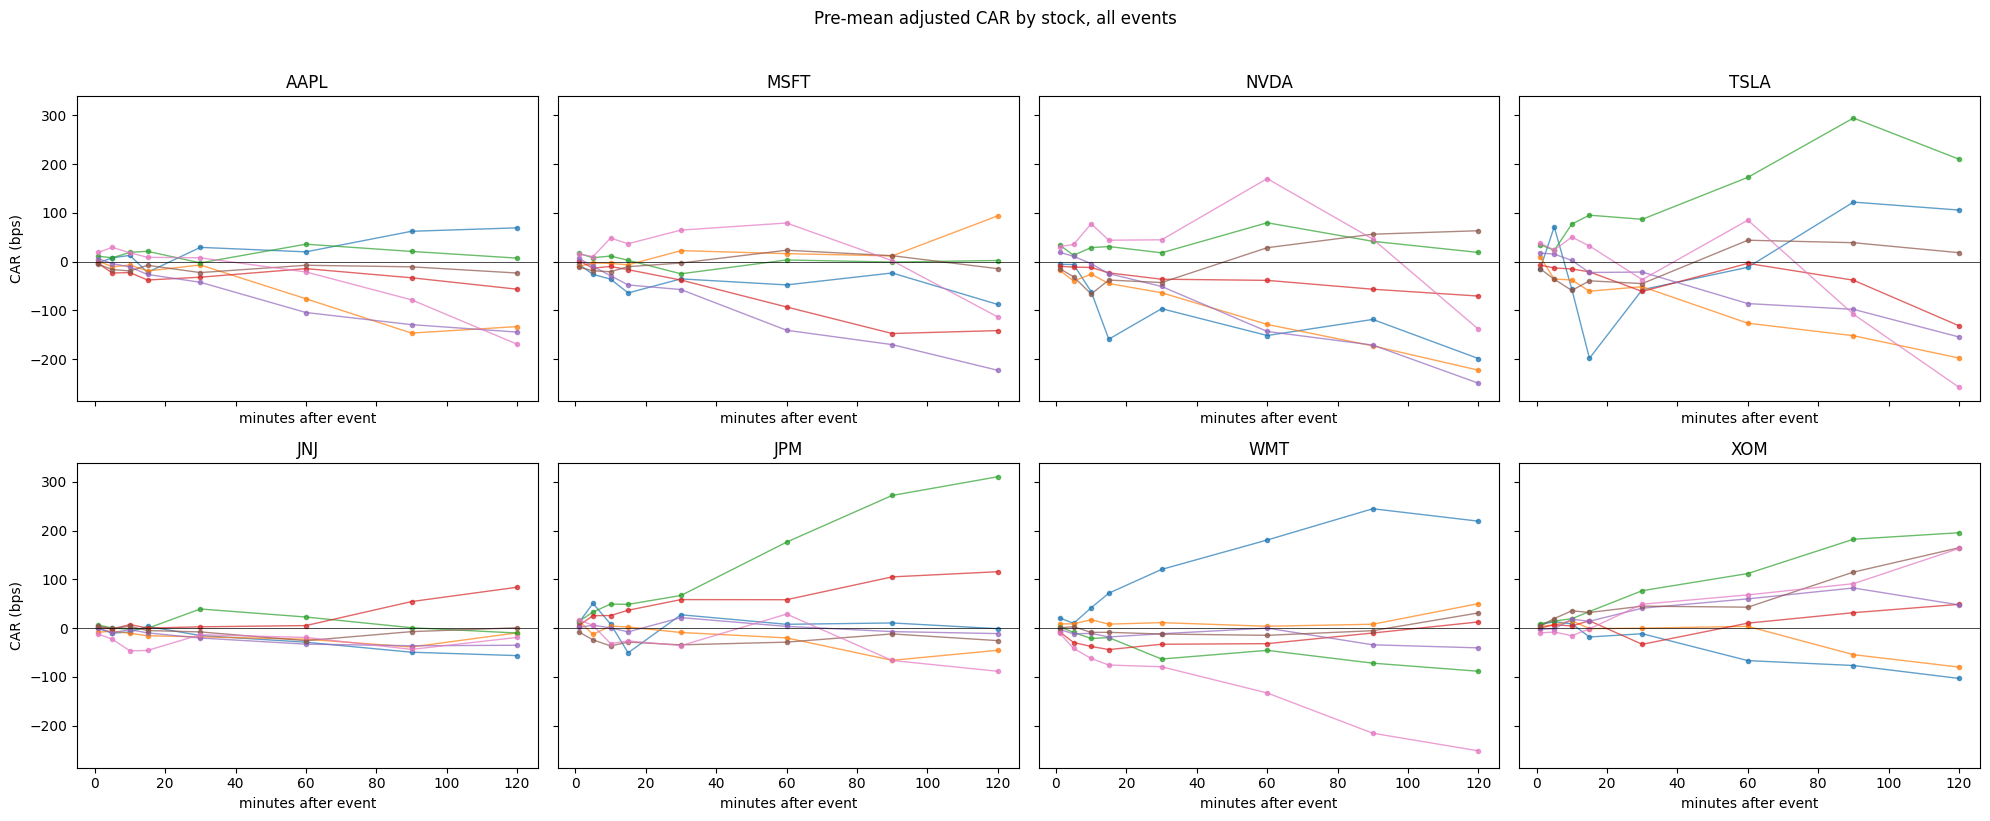

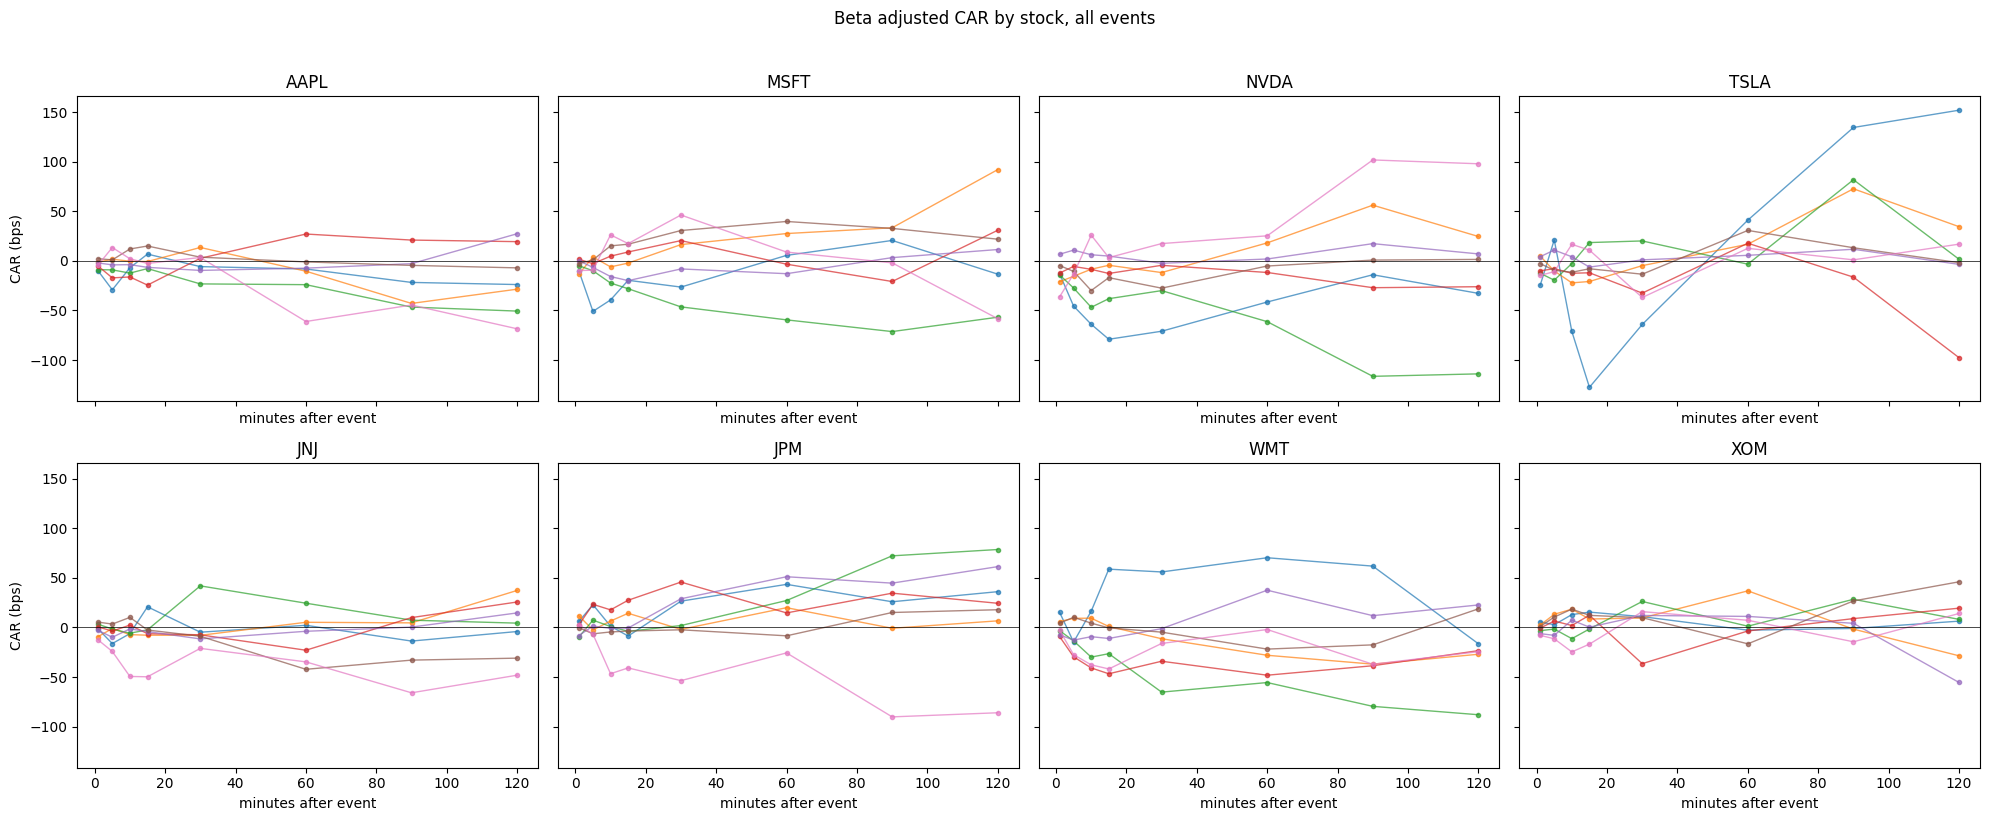

In [70]:
def plot_car_paths(car_df, stocks, car_type='car_pre_mean_bps', title_prefix='Pre-mean adjusted'):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, stock in zip(axes, stocks):
        d = car_df[car_df.ticker == stock]
        for event_id, g in d.groupby('event_id'):
            g = g.sort_values('minute')
            ax.plot(g['minute'], g[car_type], marker='o', ms=3, lw=1, alpha=0.7, label=str(event_id))
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(stock)
        ax.set_xlabel('minutes after event')
    axes[0].set_ylabel('CAR (bps)')
    axes[4].set_ylabel('CAR (bps)')
    fig.suptitle(f'{title_prefix} CAR by stock, all events', y=1.02)
    fig.tight_layout()
    plt.show()

plot_car_paths(car_df, stocks_name, car_type='car_pre_mean_bps', title_prefix='Pre-mean adjusted')
plot_car_paths(car_df, stocks_name, car_type='car_beta_adj_bps', title_prefix='Beta adjusted')

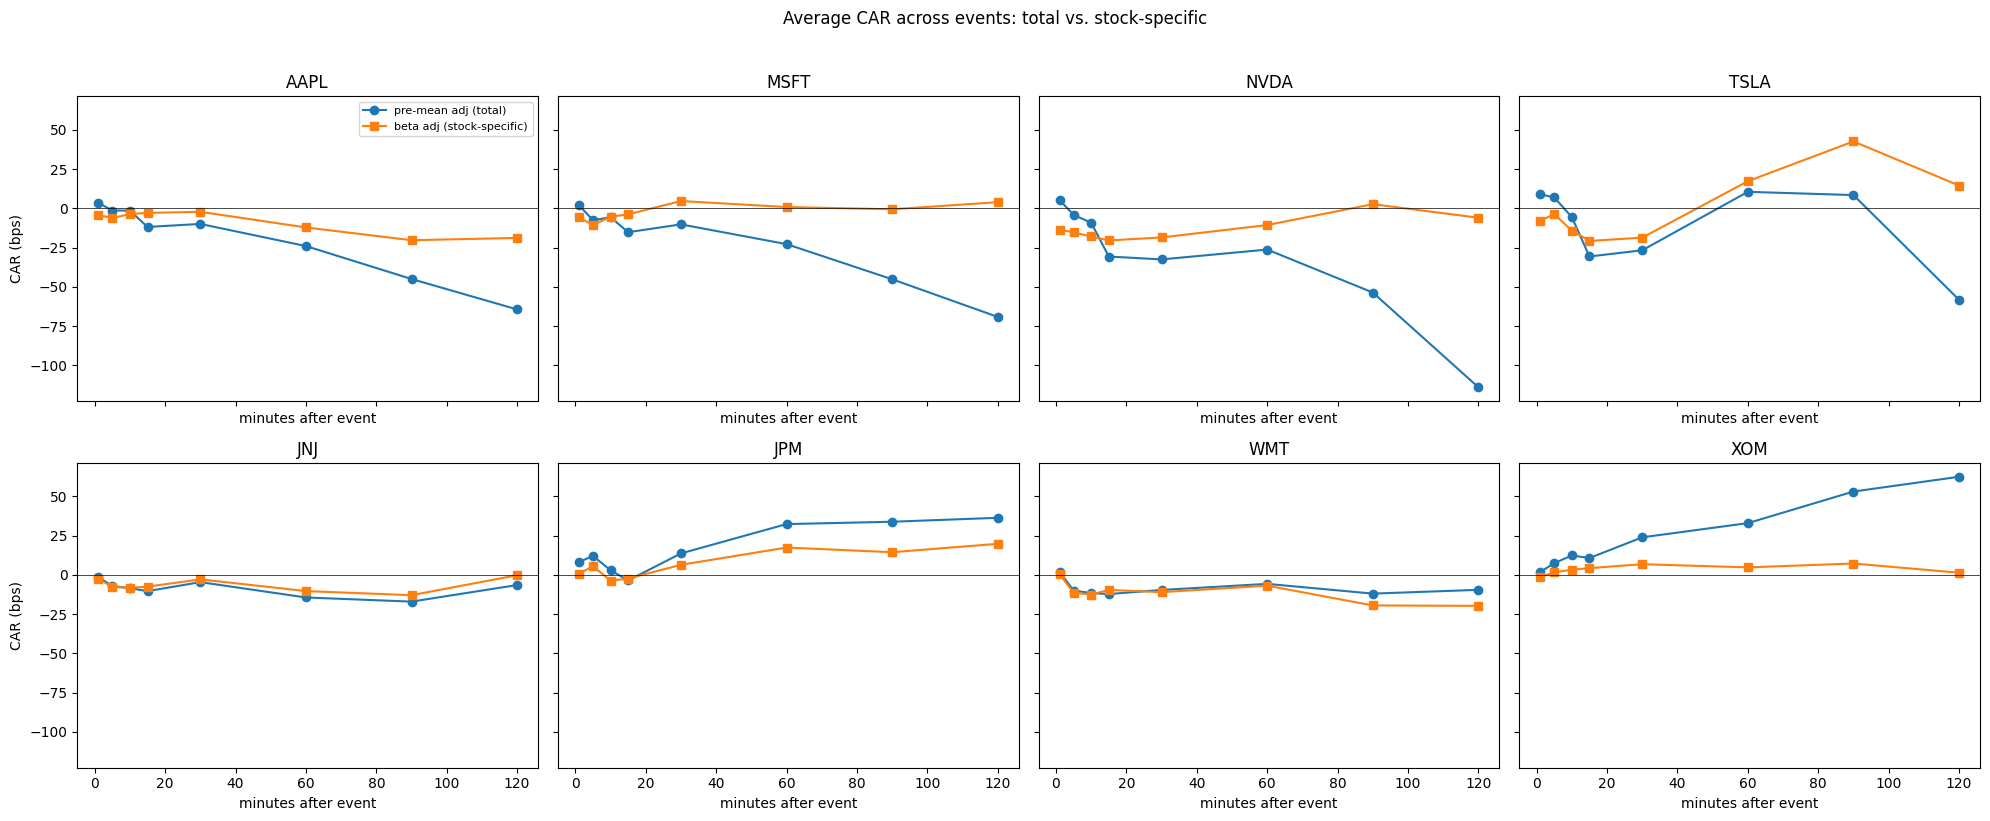

In [71]:
def plot_car_comparison(car_df, stocks):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, stock in zip(axes, stocks):
        d = car_df[car_df.ticker == stock].groupby('minute')[['car_pre_mean_bps','car_beta_adj_bps']].mean()
        ax.plot(d.index, d['car_pre_mean_bps'], marker='o', label='pre-mean adj (total)')
        ax.plot(d.index, d['car_beta_adj_bps'], marker='s', label='beta adj (stock-specific)')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(stock)
        ax.set_xlabel('minutes after event')
    axes[0].set_ylabel('CAR (bps)')
    axes[4].set_ylabel('CAR (bps)')
    axes[0].legend(fontsize=8)
    fig.suptitle('Average CAR across events: total vs. stock-specific', y=1.02)
    fig.tight_layout()
    plt.show()

plot_car_comparison(car_df, stocks_name)

In [76]:
def non_event_car(stock_close, market_close, event_time, beta_val,
                   exclude_dates=None, lookback_days=30, buffer_days=1,
                   pre_start_min=30, pre_end_min=5,
                   horizons=(1,5,10,15,30,60,90,120)):
    end_date   = (event_time - pd.Timedelta(days=buffer_days)).date()
    start_date = (event_time - pd.Timedelta(days=lookback_days + buffer_days)).date()
    clock_time = event_time.time()

    r_s = np.log(stock_close).diff()
    r_m = np.log(market_close).diff()

    rows = []
    for day in pd.date_range(start_date, end_date, freq='D'):
        day = day.date()
        if exclude_dates and day in exclude_dates:
            continue
        day_mask = r_s.index.date == day
        if not day_mask.any():
            continue

        t0 = pd.Timestamp.combine(day, clock_time).tz_localize('America/New_York')
        day_r_s = r_s[day_mask]
        day_r_m = r_m[r_m.index.date == day]

        pre = day_r_s[t0 - pd.Timedelta(minutes=pre_start_min): t0 - pd.Timedelta(minutes=pre_end_min)]
        if pre.empty or pre.isna().all():
            continue
        mu = pre.mean()
        sigma = pre.std()
        if sigma == 0 or np.isnan(sigma):
            continue

        for h in horizons:
            w = slice(t0, t0 + pd.Timedelta(minutes=h))
            r_win, m_win = day_r_s[w], day_r_m[w]
            if r_win.empty:
                continue
            car_bps = (r_win - mu).sum() * 1e4
            rows.append({
                'day': day, 'minute': h,
                'car_pre_mean_bps': car_bps,
                'car_std': car_bps / (sigma * 1e4 * np.sqrt(len(r_win))),
                'car_beta_adj_bps': (r_win - beta_val * m_win).sum() * 1e4
            })
    return pd.DataFrame(rows)

In [77]:
stock_prepared_dfs = {
    'AAPL': aapl_prepared, 'MSFT': msft_prepared, 'NVDA': nvda_prepared, 'TSLA': tsla_prepared,
    'JNJ': jnj_prepared, 'JPM': jpm_prepared, 'WMT': wmt_prepared, 'XOM': xom_prepared,
    'SPX500/USD': index_sp500_prepared
}
target_symbols = stocks_name + ['SPX500/USD']
events_for_loop = events_trimmed.reset_index(drop=True).copy()
if 'event_id' not in events_for_loop.columns:
    events_for_loop['event_id'] = events_for_loop.index

all_non_event_rows = []
skipped_non_event = []

for stock_symbol in target_symbols:
    stock_close = stock_prepared_dfs[stock_symbol][f'{stock_symbol}_close']
    market_close = stock_prepared_dfs['SPX500/USD']['SPX500/USD_close']

    for _, event in events_for_loop.iterrows():
        event_time = event['datetime_us']
        event_date_ts = pd.Timestamp(event_time.date())

        if stock_symbol == 'SPX500/USD':
            beta_val = 1.0
        else:
            beta_val = beta_df.loc[event_date_ts, stock_symbol] if event_date_ts in beta_df.index else np.nan
        if pd.isna(beta_val):
            skipped_non_event.append((event['event_id'], stock_symbol))
            continue

        exclude = all_event_dates - {event_time.date()}
        result = non_event_car(stock_close, market_close, event_time, beta_val, exclude_dates=exclude)
        if result.empty:
            skipped_non_event.append((event['event_id'], stock_symbol))
            continue

        result['event_id'] = event['event_id']
        result['ticker'] = stock_symbol
        all_non_event_rows.append(result)

non_event_car_df = pd.concat(all_non_event_rows, ignore_index=True)
print(f'{len(skipped_non_event)} event-stock pairs skipped (NaN beta or empty window)')
print(f'non_event_car_df: {non_event_car_df[["event_id","ticker"]].drop_duplicates().shape[0]} event-stock pairs, '
      f'{non_event_car_df.shape[0]} rows total')
non_event_car_df.head()

0 event-stock pairs skipped (NaN beta or empty window)
non_event_car_df: 72 event-stock pairs, 11257 rows total


,day,minute,car_pre_mean_bps,car_std,car_beta_adj_bps,event_id,ticker
0,2025-09-02,1,4.758321,1.178512,-1.123595,1,AAPL
1,2025-09-02,5,-1.209839,-0.156485,0.843751,1,AAPL
2,2025-09-02,10,-6.484485,-0.607025,3.765106,1,AAPL
3,2025-09-02,15,-11.322116,-0.872344,4.854119,1,AAPL
4,2025-09-02,30,-29.777044,-1.635527,0.565960,1,AAPL


In [81]:
car_df = car_df.merge(events_sorted[['event_id', 'direction']], on='event_id', how='left')
non_event_car_df = non_event_car_df.merge(events_sorted[['event_id', 'direction']], on='event_id', how='left')

assert car_df['direction'].isna().sum() == 0, "some event_ids didn't match — check event_id dtype/values match between car_df and events_sorted"

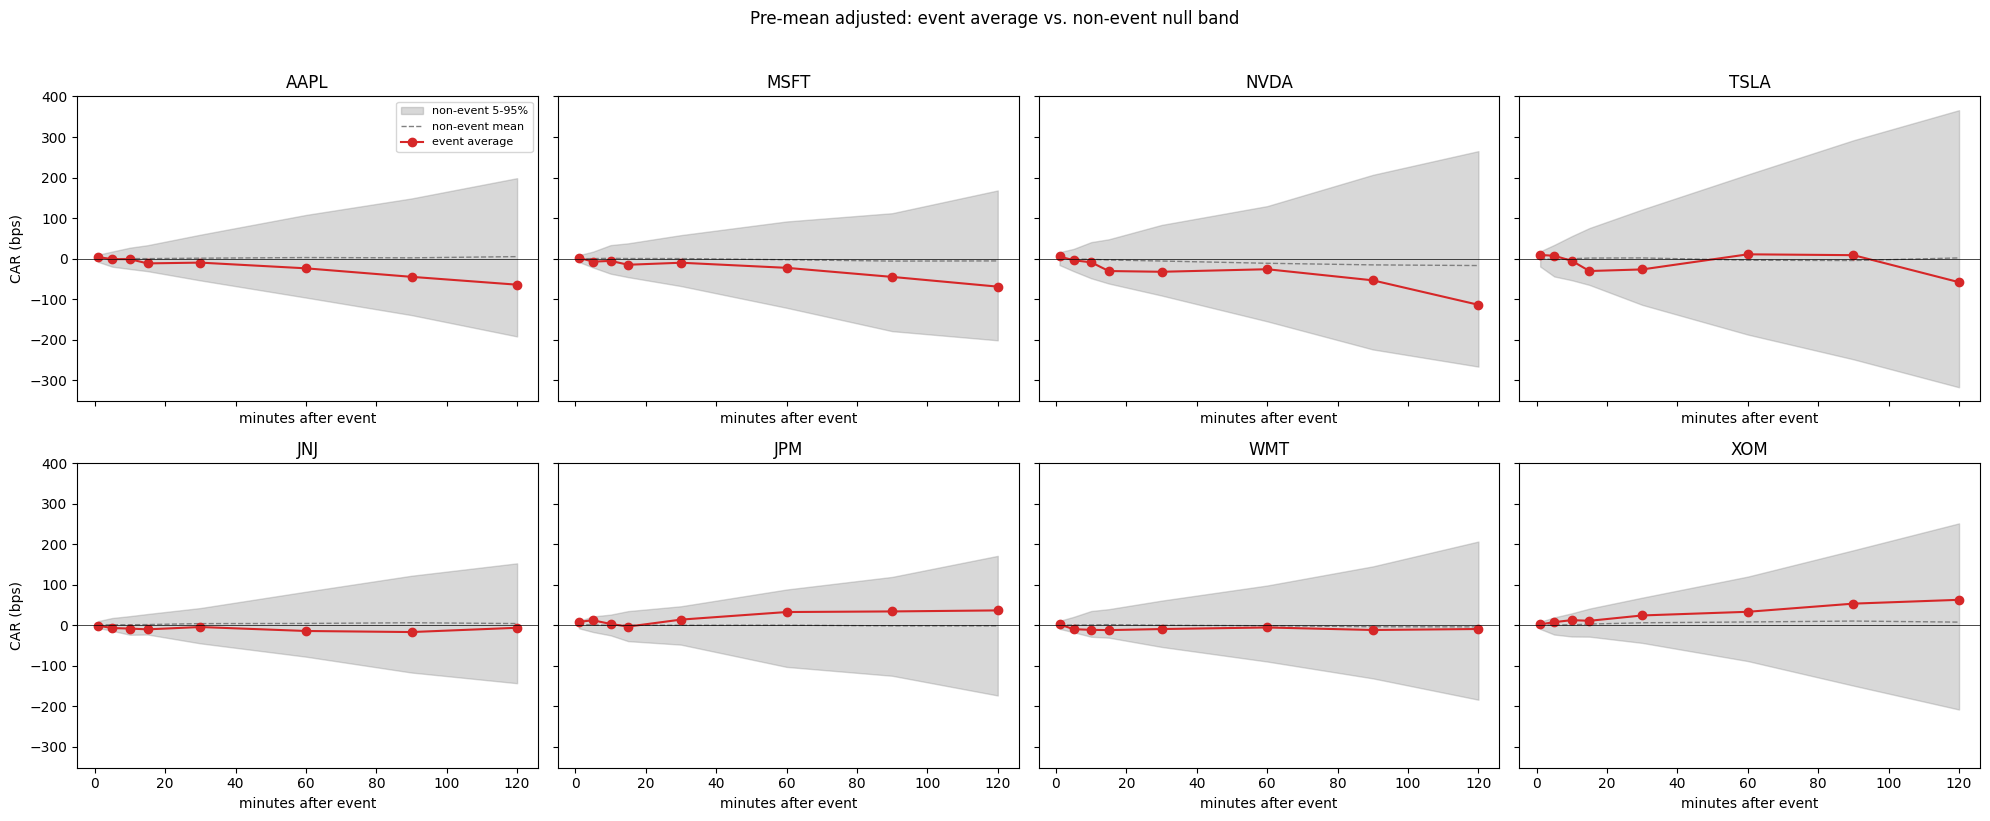

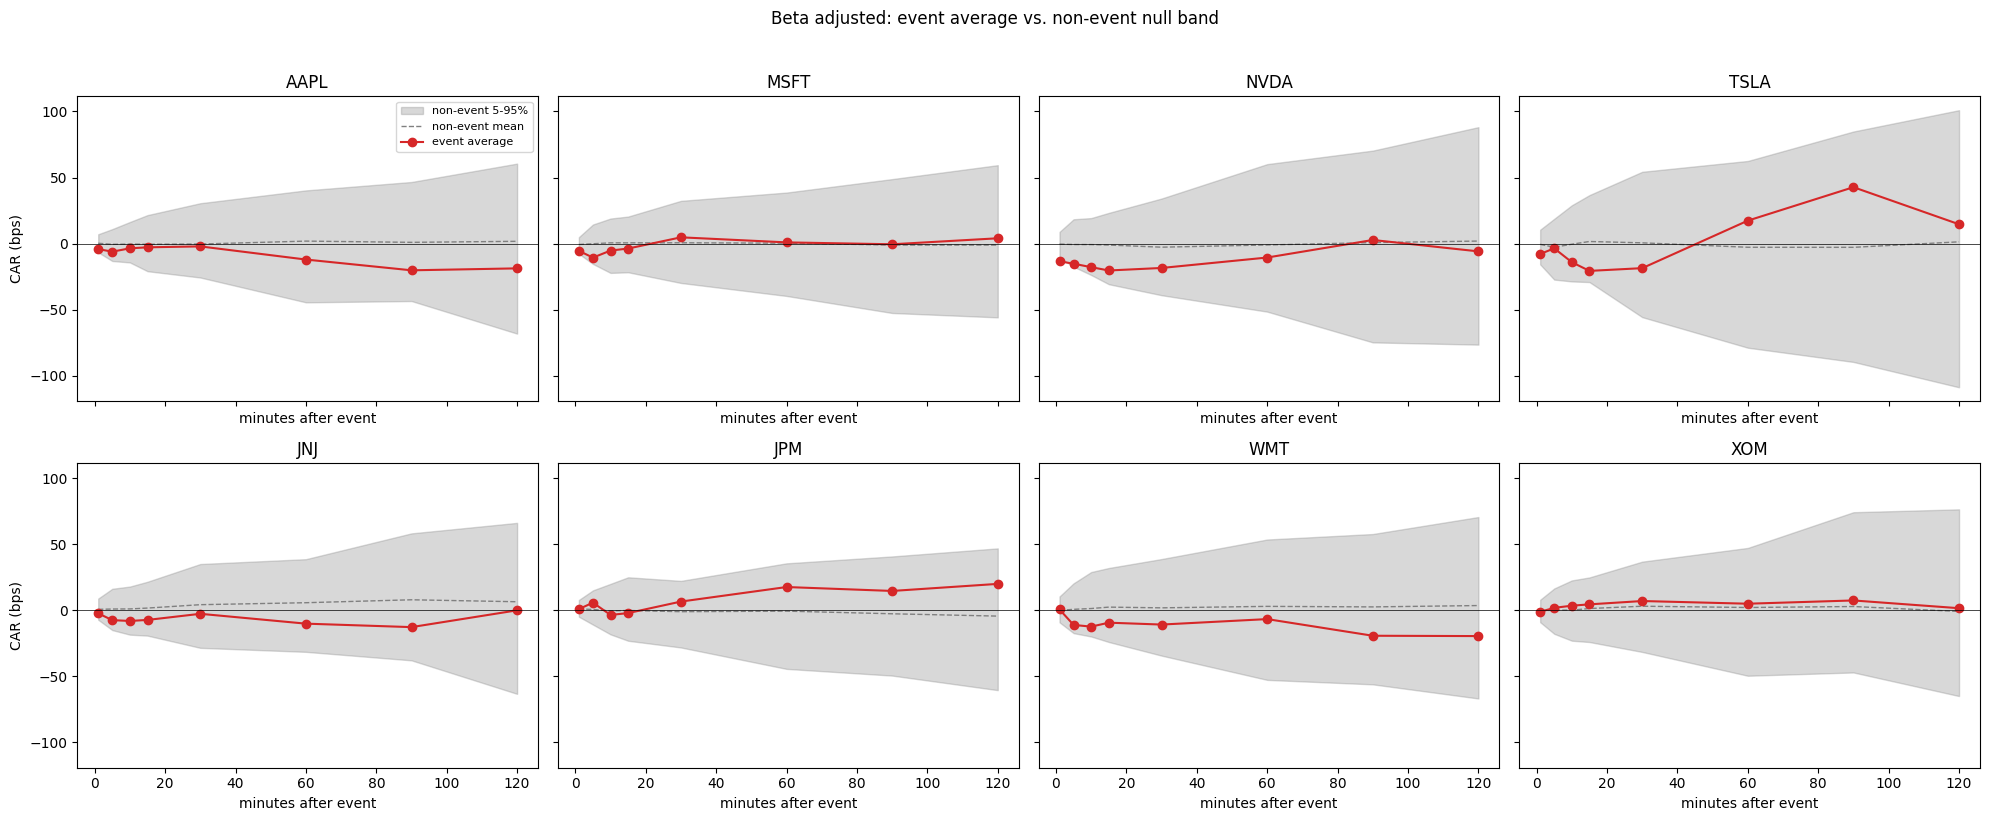

In [80]:
def summarize_and_plot(car_df, non_event_car_df, stocks, car_type='car_pre_mean_bps', title_prefix='Pre-mean adjusted'):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, stock in zip(axes, stocks):
        null = non_event_car_df[non_event_car_df.ticker == stock].groupby('minute')[car_type]
        null_mean = null.mean()
        null_lo = null.quantile(0.05)
        null_hi = null.quantile(0.95)

        event = car_df[car_df.ticker == stock].groupby('minute')[car_type].mean()

        ax.fill_between(null_mean.index, null_lo, null_hi, color='grey', alpha=0.3, label='non-event 5-95%')
        ax.plot(null_mean.index, null_mean, color='grey', lw=1, ls='--', label='non-event mean')
        ax.plot(event.index, event, color='tab:red', marker='o', lw=1.5, label='event average')

        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(stock)
        ax.set_xlabel('minutes after event')

    axes[0].set_ylabel('CAR (bps)')
    axes[4].set_ylabel('CAR (bps)')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{title_prefix}: event average vs. non-event null band', y=1.02)
    fig.tight_layout()
    plt.show()

summarize_and_plot(car_df, non_event_car_df, stocks_name, 'car_pre_mean_bps', 'Pre-mean adjusted')
summarize_and_plot(car_df, non_event_car_df, stocks_name, 'car_beta_adj_bps', 'Beta adjusted')

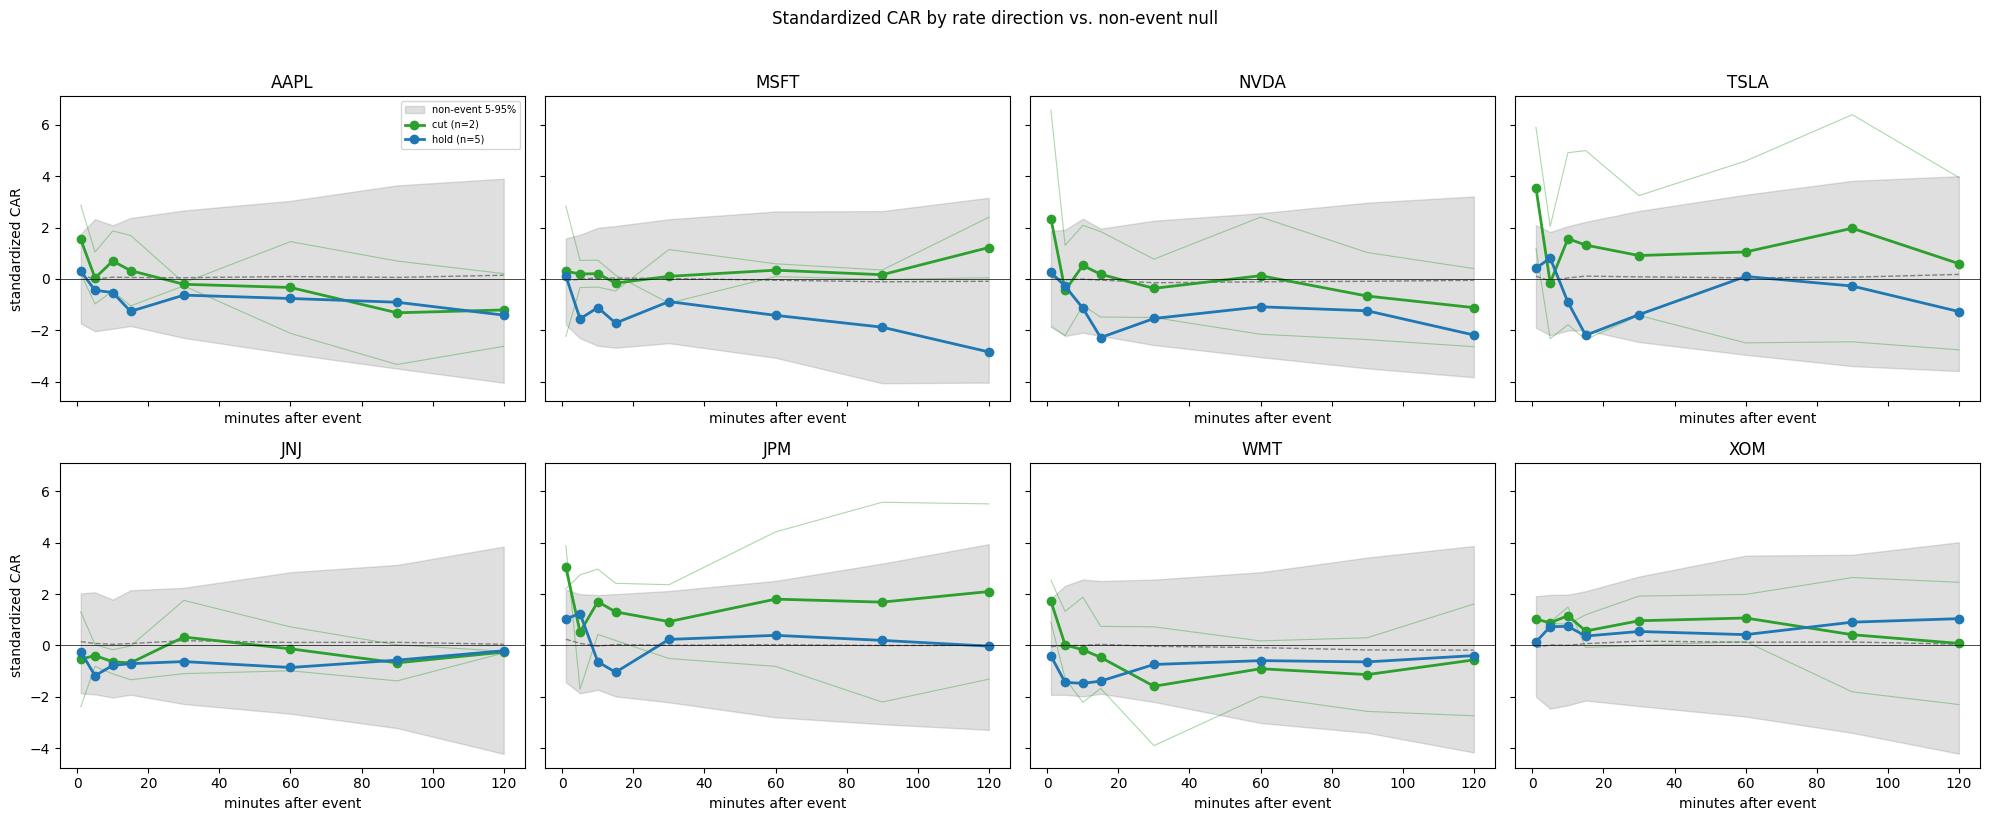

In [82]:
def summarize_and_plot_by_direction(car_df, non_event_car_df, stocks,
                                     car_type='car_std', title_prefix='Standardized CAR'):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    colors = {'hold': 'tab:blue', 'cut': 'tab:green', 'hike': 'tab:red'}

    for ax, stock in zip(axes, stocks):
        null = non_event_car_df[non_event_car_df.ticker == stock].groupby('minute')[car_type]
        ax.fill_between(null.mean().index, null.quantile(0.05), null.quantile(0.95),
                         color='grey', alpha=0.25, label='non-event 5-95%')
        ax.plot(null.mean().index, null.mean(), color='grey', lw=1, ls='--')

        d = car_df[car_df.ticker == stock]
        for direction, g in d.groupby('direction'):
            n = g.event_id.nunique()
            if n <= 2:
                for eid, gi in g.groupby('event_id'):
                    gi = gi.sort_values('minute')
                    ax.plot(gi['minute'], gi[car_type], lw=0.8, alpha=0.4, color=colors.get(direction, 'black'))
            avg = g.groupby('minute')[car_type].mean()
            ax.plot(avg.index, avg, marker='o', lw=2, color=colors.get(direction, 'black'),
                     label=f'{direction} (n={n})')

        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(stock)
        ax.set_xlabel('minutes after event')

    axes[0].set_ylabel('standardized CAR')
    axes[4].set_ylabel('standardized CAR')
    axes[0].legend(fontsize=7)
    fig.suptitle(f'{title_prefix} by rate direction vs. non-event null', y=1.02)
    fig.tight_layout()
    plt.show()

summarize_and_plot_by_direction(car_df, non_event_car_df, stocks_name, 'car_std')

In [75]:
summary_rows = []
for stock in stocks_name:
    ev = car_df[car_df.ticker == stock].groupby('minute')['car_pre_mean_bps'].mean()
    nu = non_event_car_df[non_event_car_df.ticker == stock].groupby('minute')['car_pre_mean_bps']
    nu_mean, nu_std = nu.mean(), nu.std()
    for h in ev.index:
        summary_rows.append({
            'ticker': stock, 'minute': h,
            'event_car_bps': ev.loc[h],
            'null_mean_bps': nu_mean.loc[h] if h in nu_mean.index else np.nan,
            'null_std_bps': nu_std.loc[h] if h in nu_std.index else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df['z_score'] = (summary_df['event_car_bps'] - summary_df['null_mean_bps']) / summary_df['null_std_bps']
summary_df

,ticker,minute,event_car_bps,null_mean_bps,null_std_bps,z_score
0,AAPL,1,3.638311,0.786530,5.619992,0.507435
1,AAPL,5,-1.353146,-0.407355,11.299653,-0.083701
2,AAPL,10,-1.393321,0.095724,16.235103,-0.091718
3,AAPL,15,-11.833999,-0.093506,21.599610,-0.543551
4,AAPL,30,-9.908666,0.996792,35.493189,-0.307255
...,...,...,...,...,...,...
59,XOM,15,10.782436,2.686163,22.730421,0.356187
60,XOM,30,23.977106,5.917068,36.250787,0.498197
61,XOM,60,33.024249,7.904771,64.021123,0.392362
62,XOM,90,53.146262,10.142766,98.492523,0.436617
